# AgriPotential Dataset EDA

This notebook performs exploratory data analysis on the AgriPotential dataset.

**Dataset:** AgriPotential v2 - Multi-spectral and multi-temporal remote sensing dataset for agricultural potential prediction

**Key Features:**
- 34 Sentinel-2 timeframes
- 10 spectral bands per timeframe
- 5 agricultural potential classes (very low to very high)
- 3 crop types: viticulture, market gardening, field crops

**Reference:** https://huggingface.co/datasets/m-sakka/agripotential

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
# Core libraries
import sys
import warnings
import logging
import os
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch and data
import torch
import rasterio
from torch.utils.data import DataLoader, Subset
from rasterio.windows import Window

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from utils.constants import *
from utils.visualization import *

# Suppress warnings
warnings.filterwarnings("ignore")
logging.getLogger('rasterio').setLevel(logging.ERROR)

In [2]:
# Check PyTorch and device
print(f"PyTorch version: {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

PyTorch version: 2.10.0+cu128
Device: cuda


## Load Dataset
The dataset has a size of 200 GB. For this EDA we download a single timeframe.

In [3]:
# Configuration
CROP_TYPE = "viticulture"
DATA_DIR = "../src/data/"  # Directory to store downloaded data
TIMEFRAME_TO_DOWNLOAD = 0 # Timeframe to download

In [4]:
import requests
from pathlib import Path

def download_file(url, dest_path, desc="file", timeout=30):
    """
    Download a file from URL to destination path
    
    Args:
        url: Source URL
        dest_path: Destination file path
        desc: Description for progress
    """
    dest_path = Path(dest_path)
    dest_path.parent.mkdir(parents=True, exist_ok=True)

    if dest_path.exists():
        print(f"✓ {desc} already exists at {dest_path}")
        return

    print(f"Downloading {desc}...")

    try:
        with requests.get(url, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            with open(dest_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

        print(f"✓ Downloaded {desc} to {dest_path}")

    except requests.RequestException as e:
        print(f"✗ Failed to download {desc}: {e}")

In [7]:
# Create data directory
os.makedirs(DATA_DIR, exist_ok=True)

# Download CSV files
print("Downloading CSV files...")
download_file(DATASET_URL + "metadata.csv", DATA_DIR + "metadata.csv", "metadata")
download_file(DATASET_URL + "train.csv", DATA_DIR + "train.csv", "train patches")
download_file(DATASET_URL + "val.csv", DATA_DIR + "val.csv", "val patches") 
download_file(DATASET_URL + "test.csv", DATA_DIR + "test.csv", "test patches")

# Load metadata to get filename
metadata = pd.read_csv(DATA_DIR + "metadata.csv")
sentinel_filename = metadata.iloc[TIMEFRAME_TO_DOWNLOAD]["filename"]
sentinel_path = DATA_DIR + sentinel_filename

# Download Sentinel-2 file
download_file(
    DATASET_URL + sentinel_filename,
    sentinel_path,
    f"Sentinel-2 timeframe {TIMEFRAME_TO_DOWNLOAD}"
)

label_path = DATA_DIR + f"{CROP_TYPE}.tif"

# Download label file
download_file(
    DATASET_URL + f"{CROP_TYPE}.tif",
    label_path,
    f"{CROP_TYPE} labels"
)

✓ metadata already exists at ..\src\data\metadata.csv
✓ train patches already exists at ..\src\data\train.csv
✓ val patches already exists at ..\src\data\val.csv
✓ test patches already exists at ..\src\data\test.csv
✓ Sentinel-2 timeframe 0 already exists at ..\src\data\T31TEJ_2017_01_03.tif
✓ viticulture labels already exists at ..\src\data\viticulture.tif


In [6]:
# Load patch information
train_df = pd.read_csv(DATA_DIR + "train.csv")
print(f"Total training patches: {len(train_df)}")
train_df.head()

Total training patches: 6329


,patch_id,row,col,patch_size,n_annotated
0,7296_14720,7296,14720,128,1724
1,5120_12672,5120,12672,128,4575
2,5184_12608,5184,12608,128,863
3,5184_12672,5184,12672,128,4077
4,5248_12608,5248,12608,128,1324


## Load Patches with Rasterio

In [7]:
sentinel_src = rasterio.open(sentinel_path)
label_src = rasterio.open(label_path)

print(f"\nSentinel-2 metadata:")
print(f"  Width: {sentinel_src.width}, Height {sentinel_src.height}")
print(f"  Bands: {sentinel_src.count}")
print(f"  Data type: {sentinel_src.dtypes[0]}")


Sentinel-2 metadata:
  Width: 18770, Height 15286
  Bands: 10
  Data type: int16


In [8]:
X_list = []
y_list = []
patch_ids = []

for idx in range(len(train_df)):
    patch_info = train_df.iloc[idx]
    patch_row = patch_info["row"]
    patch_col = patch_info["col"]
    patch_size = patch_info["patch_size"]
    patch_id = patch_info["patch_id"]
    
    # Read window (patch) from both files
    window = Window(patch_col, patch_row, patch_size, patch_size)
    sentinel_patch = sentinel_src.read(window=window)
    label_patch = label_src.read(window=window)[0]
    
    X_list.append(sentinel_patch)
    y_list.append(label_patch)
    patch_ids.append(patch_id)

X_train = np.array(X_list) / SENTINEL2_MAX # Default normalization, we can try a different one on the model later.
y_train = np.array(y_list)

print(f"Loaded {len(X_train)} patches")
print(f"X shape: {X_train.shape}")  # Expected: (N, C, H, W)
print(f"y shape: {y_train.shape}")  # Expected: (N, H, W)

# Close files
# sentinel_src.close()
# label_src.close()

Loaded 6329 patches
X shape: (6329, 10, 128, 128)
y shape: (6329, 128, 128)


## Class Distribution Analysis (pixel-level)

In [13]:
# Note: Labels are at pixel level, with 0 = unlabelled
all_labels = y_train.flatten()
labelled_pixels = all_labels[all_labels > 0]

print(f"Total pixels: {len(all_labels):,}")
print(f"Labelled pixels: {len(labelled_pixels):,} ({100*len(labelled_pixels)/len(all_labels):.1f}%)")
print(f"Unlabelled pixels: {np.sum(all_labels == 0):,}")

Total pixels: 103,694,336
Labelled pixels: 65,187,229 (62.9%)
Unlabelled pixels: 38,507,107


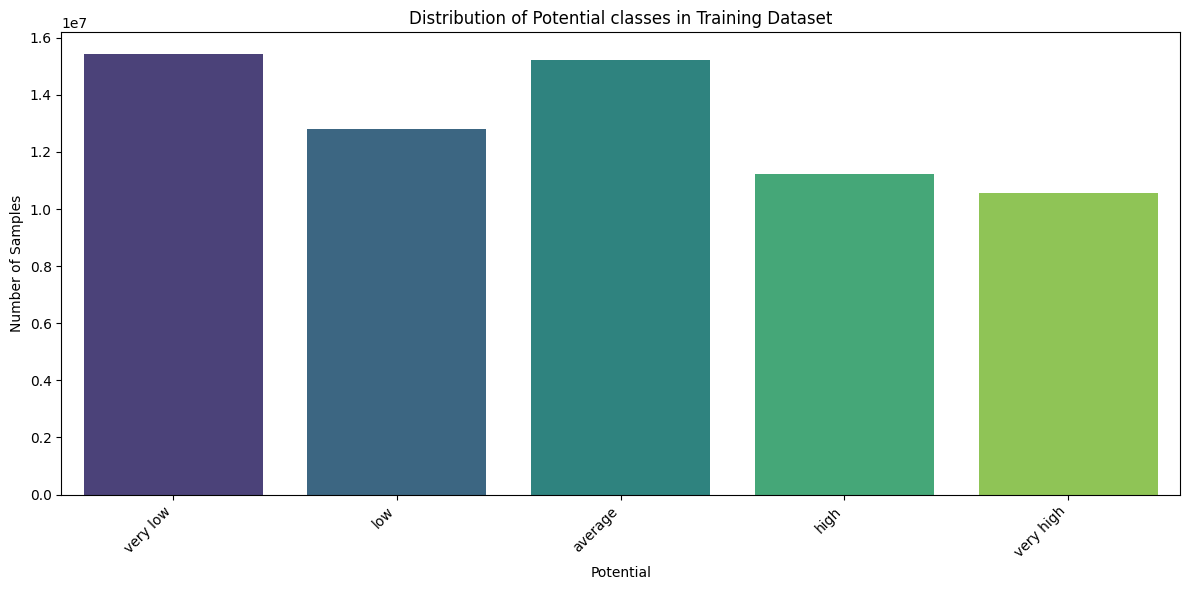

In [14]:
plot_class_distribution(labelled_pixels, [ID_TO_CLASS[i] for i in range(len(POTENTIAL_CLASSES))],  "Distribution of Potential classes in Training Dataset")

## Class Distribution Analysis (patch-level)

In [15]:
# Analyze each patch's dominant class
patch_dominant_classes = []
patch_labelled_ratios = []

for patch_labels in y_train:
    patch_labels = patch_labels.flatten()
    labelled = patch_labels[patch_labels > 0]
    
    if len(labelled) > 0:
        dominant = np.bincount(labelled).argmax()
        patch_dominant_classes.append(dominant)
        patch_labelled_ratios.append(len(labelled) / len(patch_labels))
    else:
        patch_dominant_classes.append(0)
        patch_labelled_ratios.append(0.0)

patch_dominant_classes = np.array(patch_dominant_classes)
patch_labelled_ratios = np.array(patch_labelled_ratios)

print(f"Patches with >50% labelled pixels: {np.sum(patch_labelled_ratios > 0.5)}")
print(f"Mean labelled ratio: {patch_labelled_ratios.mean():.2%}")

Patches with >50% labelled pixels: 3928
Mean labelled ratio: 62.86%


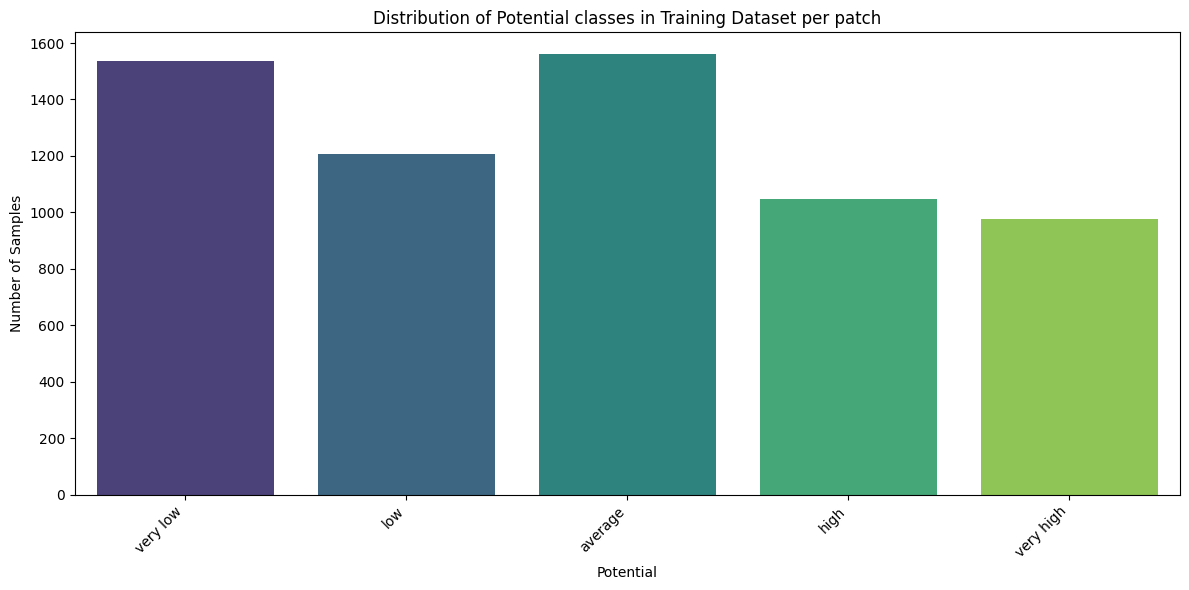

In [16]:
plot_class_distribution(patch_dominant_classes, [ID_TO_CLASS[i] for i in range(len(POTENTIAL_CLASSES))],  "Distribution of Potential classes in Training Dataset per patch")

## Visualization

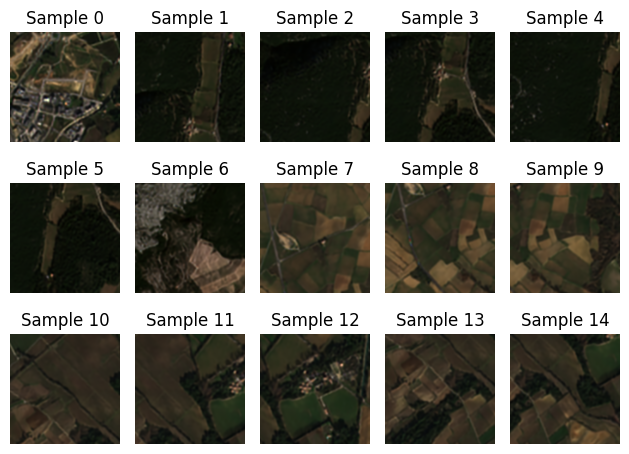

In [55]:
# Show sample patches
for id in range(0, 15):
    plt.subplot(3, 5, id + 1)
    show_rgb(X_train, idx=id)
    plt.title(f"Sample {id}")
plt.tight_layout()
plt.show()

No samples found for class: unlabelled


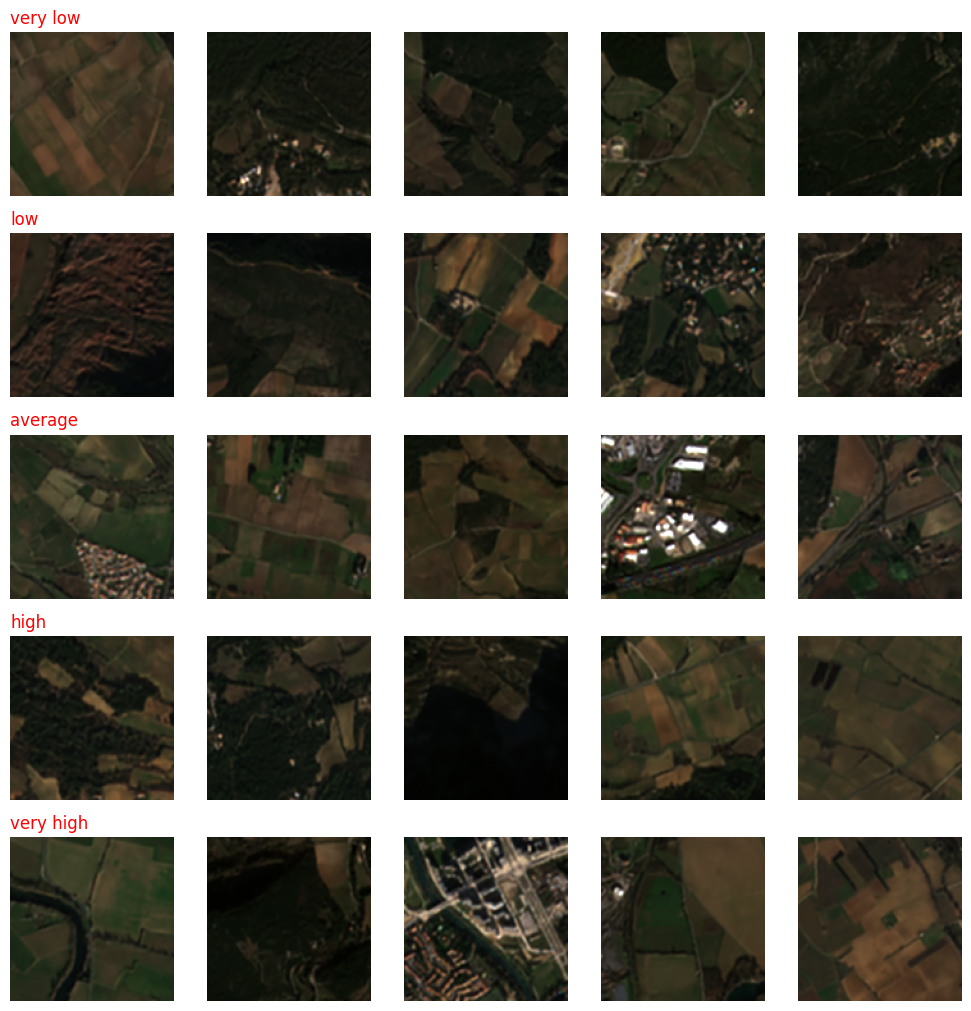

In [20]:
# Plot by class
plot_by_class(X_train, patch_dominant_classes, ID_TO_CLASS, samples_per_class=5)

## Spectral band Analysis

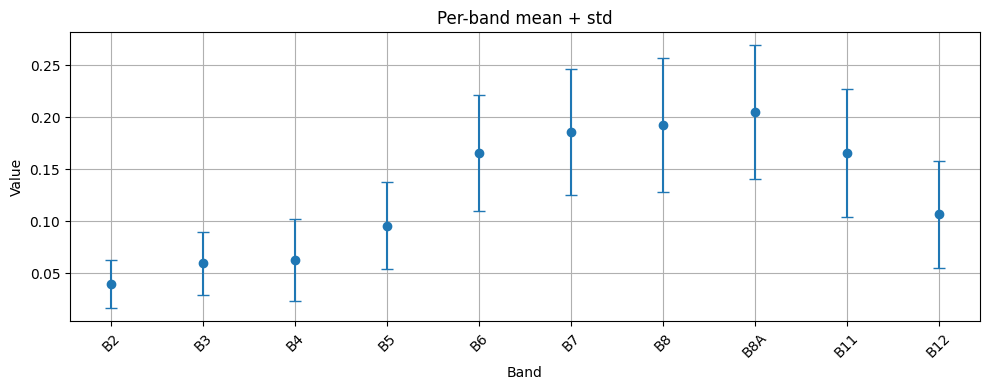

In [24]:
plot_band_statistics(X_train, BAND_NAMES)

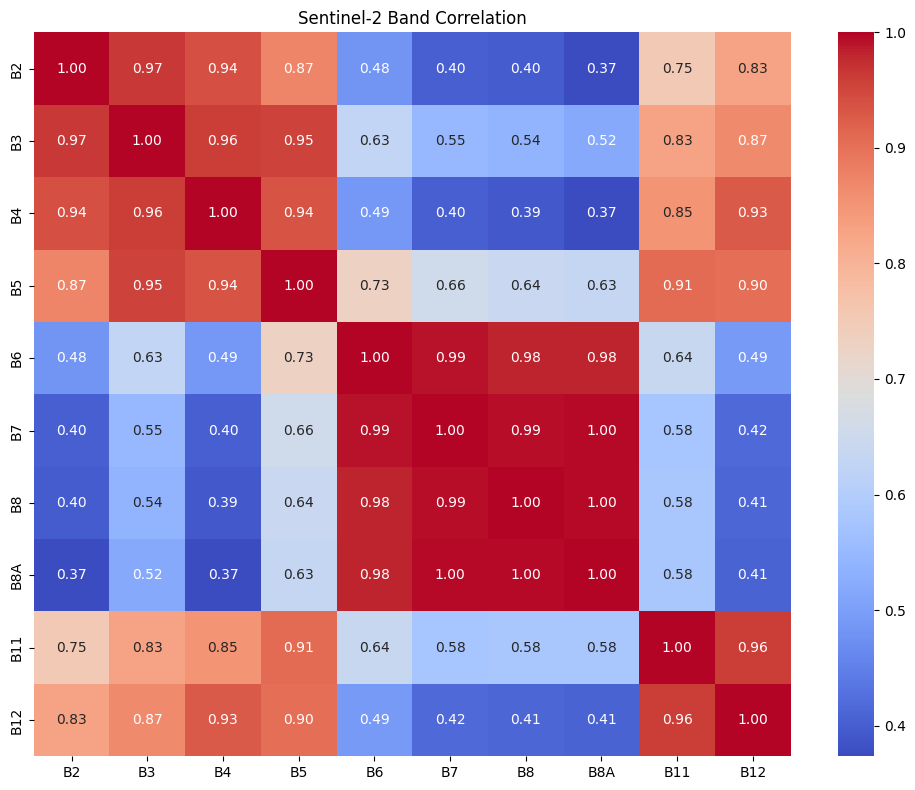

In [27]:
plot_band_correlation(X_train, BAND_NAMES)

## PCA Analysis

In [9]:
y_train.shape

(6329, 128, 128)

In [10]:
# Move channels to last dimension
X_tmp = np.moveaxis(X_train, 1, -1)  # (N, H, W, 10)

X_pixels = X_tmp[y_train > 0]
y_pixels = y_train[y_train > 0]

print(X_pixels.shape)

(65187229, 10)


In [12]:
# subsample
n_samples = 300_000

idx = np.random.choice(X_pixels.shape[0], n_samples, replace=False)
X_sample = X_pixels[idx]
y_sample = y_pixels[idx]

print("Using samples:", X_sample.shape[0])

Using samples: 300000


Explained variance per component:
PC1: 0.7015
PC2: 0.2516
PC3: 0.0349
PC4: 0.0067
PC5: 0.0021
PC6: 0.0015
PC7: 0.0010
PC8: 0.0004
PC9: 0.0002
PC10: 0.0001


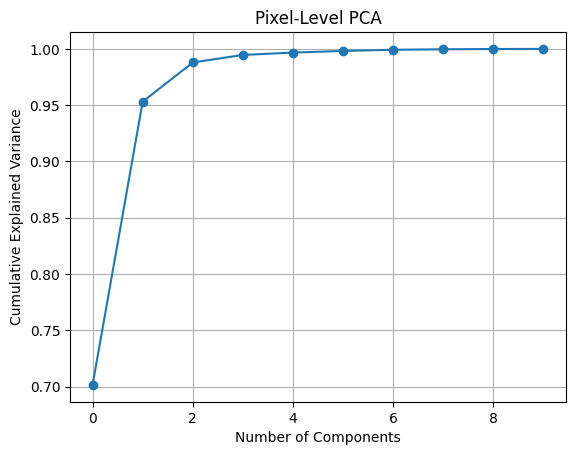

In [13]:
plot_pca(X_sample)

## Feature Importance via Mutual Information

Mutual Information per band:
Band 0: 0.0544
Band 1: 0.0533
Band 2: 0.0557
Band 3: 0.0592
Band 4: 0.0240
Band 5: 0.0168
Band 6: 0.0172
Band 7: 0.0188
Band 8: 0.0534
Band 9: 0.0547


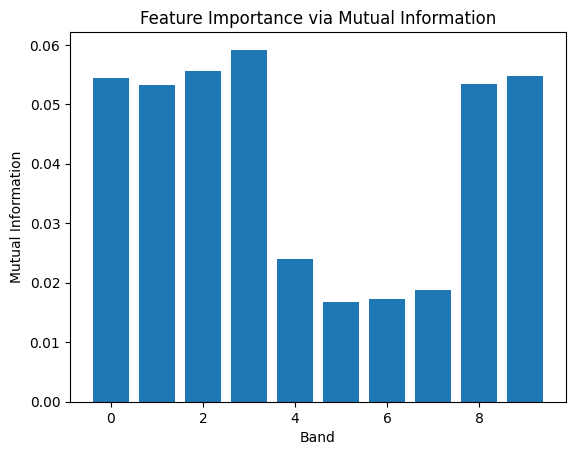

In [14]:
plot_mutual_info(X_sample, y_sample)